In [37]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://applying-python-to-data-analytics.nathanmichalewicz.org/09-univariate-visualizations/airbnb_data.csv"
df = pd.read_csv(url)
df.head()

/var/folders/51/98hfxykd757g35tkvqr8g0r00000gn/T/ipykernel_4106/1690798113.py:6: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [38]:
df.columns
df.isnull().sum()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [39]:
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    mean = df[col].mean()
    median = df[col].median()
    std = df[col].std()
print(f"{col}: mean = {mean:.3f}; median = {median: .3f}; std = {std:.3f}")

availability 365: mean = 141.133; median =  96.000; std = 135.435


In [40]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    vals = df[col].dropna().unique()
    print(f"{col}: {len(vals)} unique values")
    if len(vals) < 10:
        print(f"{vals}")

NAME: 61281 unique values
host_identity_verified: 2 unique values
['unconfirmed' 'verified']
host name: 13190 unique values
neighbourhood group: 7 unique values
['Brooklyn' 'Manhattan' 'brookln' 'manhatan' 'Queens' 'Staten Island'
 'Bronx']
neighbourhood: 224 unique values
country: 1 unique values
['United States']
country code: 1 unique values
['US']
instant_bookable: 2 unique values
[False True]
cancellation_policy: 3 unique values
['strict' 'moderate' 'flexible']
room type: 4 unique values
['Private room' 'Entire home/apt' 'Shared room' 'Hotel room']
price: 1151 unique values
service fee: 231 unique values
last review: 2477 unique values
house_rules: 1976 unique values
license: 1 unique values
['41662/AL']


In [41]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols


Index(['NAME', 'host_identity_verified', 'host name', 'neighbourhood group',
       'neighbourhood', 'country', 'country code', 'instant_bookable',
       'cancellation_policy', 'room type', 'price', 'service fee',
       'last review', 'house_rules', 'license'],
      dtype='object')

In [42]:
df["neighbourhood"].isnull().sum()

np.int64(16)

In [43]:
std = df["review rate number"].std()
print(f"{std: .2f}")

 1.28


In [44]:
reviews =  df["number of reviews"]
sk = stats.skew(reviews, nan_policy="omit")
kurt = stats.kurtosis(reviews, nan_policy="omit")

print(f"{sk=:.2f}")
print(f"{kurt=:.2f}")

sk=3.84
kurt=25.03


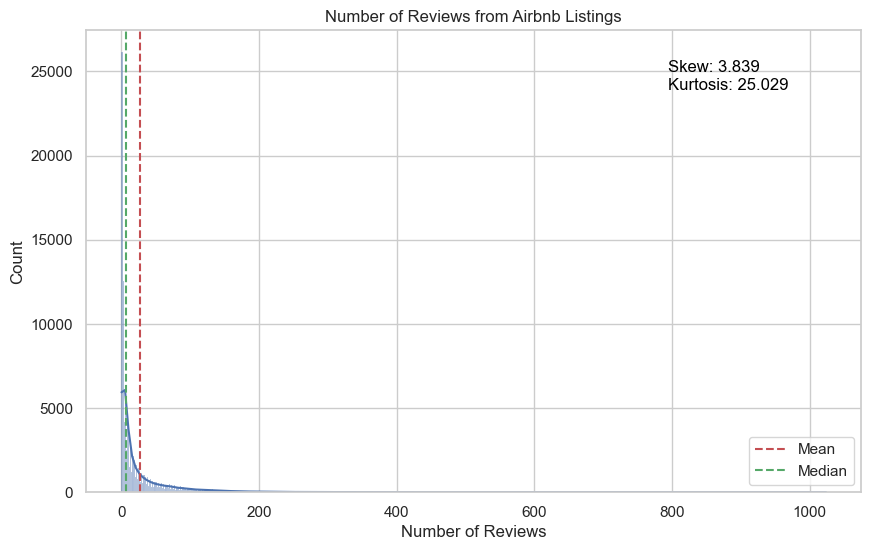

In [47]:
reviews = df["number of reviews"]
sk = stats.skew(reviews, nan_policy="omit")
kurt = stats.kurtosis(reviews, nan_policy="omit")

plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
hist = sns.histplot(data=df, x="number of reviews", kde=True, line_kws={"color": "r"})
plt.title("Number of Reviews from Airbnb Listings")
plt.xlabel("Number of Reviews")
plt.ylabel("Count")
plt.axvline(x=reviews.mean(), color="r", linestyle="--", label="Mean")
plt.axvline(x=reviews.median(), color="g", linestyle="--", label="Median")
text = f"Skew: {sk:.3f}\nKurtosis: {kurt:.3f}"
plt.text(
    x=0.75,
    y=0.90,
    s=text,
    va="center",
    fontsize=12,
    color="black",
    transform=plt.gca().transAxes
)
plt.legend()
plt.show()

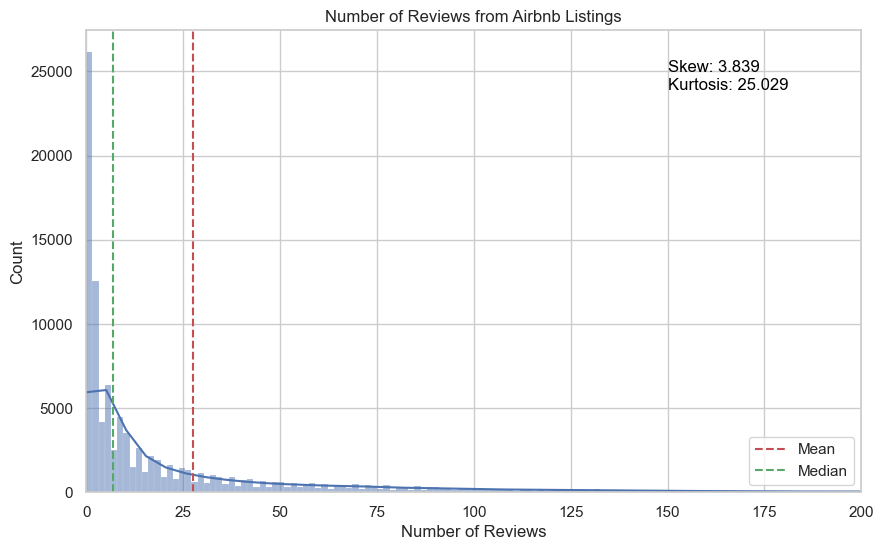

In [48]:
reviews = df["number of reviews"]
sk = stats.skew(reviews, nan_policy="omit")
kurt = stats.kurtosis(reviews, nan_policy="omit")

plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
hist = sns.histplot(data=df, x="number of reviews", kde=True, line_kws={"color": "r"})
plt.title("Number of Reviews from Airbnb Listings")
plt.xlabel("Number of Reviews")
plt.ylabel("Count")
plt.xlim(0,200)
plt.axvline(x=reviews.mean(), color="r", linestyle="--", label="Mean")
plt.axvline(x=reviews.median(), color="g", linestyle="--", label="Median")
text = f"Skew: {sk:.3f}\nKurtosis: {kurt:.3f}"
plt.text(
    x=0.75,
    y=0.90,
    s=text,
    va="center",
    fontsize=12,
    color="black",
    transform=plt.gca().transAxes
)
plt.legend()
plt.show()

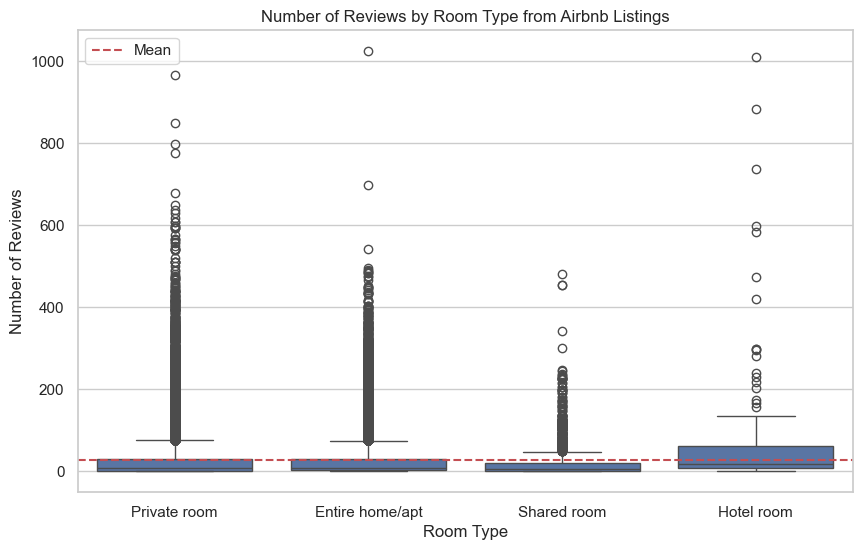

In [52]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
ht_boxes = sns.boxplot(data=df, x="room type", y="number of reviews")
plt.axhline(y=reviews.mean(), color="r", linestyle="--", label="Mean")
plt.title("Number of Reviews by Room Type from Airbnb Listings")
plt.xlabel("Room Type")
plt.ylabel("Number of Reviews")
plt.legend()
plt.show()

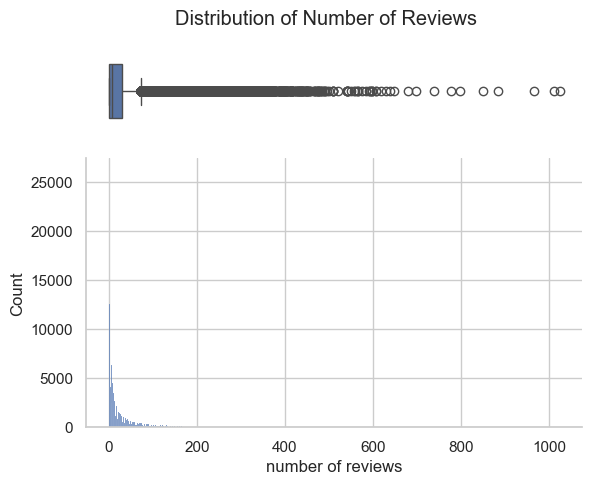

In [55]:
def multiplot(df: pd.DataFrame, col: str, xlabel=str):
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, height_ratios=[2,8])
    box = sns.boxplot(data=df, x=col, ax=ax1)
    hist = sns.histplot(data=df, x=col, ax=ax2)
    box.set(xlabel="", xticks=[], yticks=[])
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    hist.set(xlabel=xlabel)
    plt.suptitle("Distribution of Number of Reviews")
    plt.show()

multiplot(df=df, col="number of reviews", xlabel="number of reviews")